# Projeto Integrador — Abandono Escolar em Cubatão-SP
### Censo Escolar, Taxas de Rendimento e estudo de caso (2026) — recorte Anos Finais (6º ao 9º ano)

**Escopo:** rede municipal de Cubatão-SP, Ensino Fundamental Anos Finais (6º a 9º ano).

1. **Censo Escolar (2024 x 2025)** — escolas, matrículas, turmas e docentes, 7º ano e Anos Finais (6º-9º)
2. **Taxas de Rendimento (2024 x 2025)** — aprovação, reprovação e abandono, oficiais do INEP, 7º ano e Anos Finais
3. **Estudo de caso (2026)** — frequência de uma escola (nome fictício "Escola Municipal de Cubatão"), 16 turmas cobrindo 6º ao 9º ano
4. **Índice de risco combinado** — agora com "série" como variável real (4 categorias)
5. **Síntese e próximos passos**

> ⚠️ **Transparência sobre origem dos dados do estudo de caso:** as turmas de **7º, 8º e 9º ano são dados reais**, digitalizados a partir da chamada da escola. As turmas de **6º ano são fictícias** (simuladas com o mesmo método estatístico usado para o turno da tarde), porque o arquivo original não continha 6º ano. Toda tabela e gráfico do Bloco 3 identifica a origem.
>
> **Nota sobre o histórico SEDUC-SP (2011–2024):** avaliado e descartado — cobre a rede estadual de Cubatão, sem correspondência com as escolas municipais do Censo. As Taxas de Rendimento do INEP (Bloco 2) resolvem essa lacuna para a rede municipal.


In [1]:
# 0. Setup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 5)

DADOS = "../dados_escola_cubatao_completo"
CO_MUNICIPIO_CUBATAO = 3513504

COR_2024 = '#4C72B0'
COR_2025 = '#DD8452'


## 1. Censo Escolar — rede municipal de Cubatão (2024 x 2025)

7º ano isolado e Anos Finais completos (6º-9º) lado a lado.


In [2]:
# 1.1 Carregar e isolar a rede municipal em cada ano
ed_basica_2024 = pd.read_csv(f"{DADOS}/2024_cubatao_educacao_basica.csv", sep=';')
escola_2025 = pd.read_csv(f"{DADOS}/2025_cubatao_escola.csv", sep=';')
matricula_2025 = pd.read_csv(f"{DADOS}/2025_cubatao_matricula.csv", sep=';')
turma_2025 = pd.read_csv(f"{DADOS}/2025_cubatao_turma.csv", sep=';')
docente_2025 = pd.read_csv(f"{DADOS}/2025_cubatao_docente.csv", sep=';')

ed_basica_mun_2024 = ed_basica_2024[ed_basica_2024['TP_DEPENDENCIA'] == 3].copy()
escola_mun_2025 = escola_2025[escola_2025['TP_DEPENDENCIA'] == 3].copy()
matricula_mun_2025 = matricula_2025[matricula_2025['TP_DEPENDENCIA'] == 3].copy()
turma_mun_2025 = turma_2025[turma_2025['TP_DEPENDENCIA'] == 3].copy()
docente_mun_2025 = docente_2025[docente_2025['TP_DEPENDENCIA'] == 3].copy()

print(f"Escolas municipais — 2024: {ed_basica_mun_2024['NO_ENTIDADE'].nunique()} | 2025: {escola_mun_2025['NO_ENTIDADE'].nunique()}")


Escolas municipais — 2024: 57 | 2025: 54


In [3]:
# 1.2 Painel geral — 7º ano x Anos Finais (6º-9º), 2024 x 2025
resumo = pd.DataFrame({
    '2024': [
        ed_basica_mun_2024['QT_MAT_FUND_AF_7'].sum(),
        ed_basica_mun_2024['QT_MAT_FUND_AF'].sum(),
        ed_basica_mun_2024['QT_DOC_FUND_AF'].sum(),
    ],
    '2025': [
        matricula_mun_2025['QT_MAT_FUND_AF_7'].sum(),
        matricula_mun_2025['QT_MAT_FUND_AF'].sum(),
        docente_mun_2025['QT_DOC_FUND_AF'].sum(),
    ]
}, index=['Matrículas — 7º ano', 'Matrículas — Anos Finais (6º-9º)', 'Docentes — Anos Finais (6º-9º)'])

resumo['Variação'] = resumo['2025'] - resumo['2024']
resumo['Variação %'] = (resumo['Variação'] / resumo['2024'] * 100).round(1)
resumo


,2024,2025,Variação,Variação %
Matrículas — 7º ano,915.0,919,4.0,0.4
Matrículas — Anos Finais (6º-9º),3416.0,3488,72.0,2.1
Docentes — Anos Finais (6º-9º),287.0,272,-15.0,-5.2


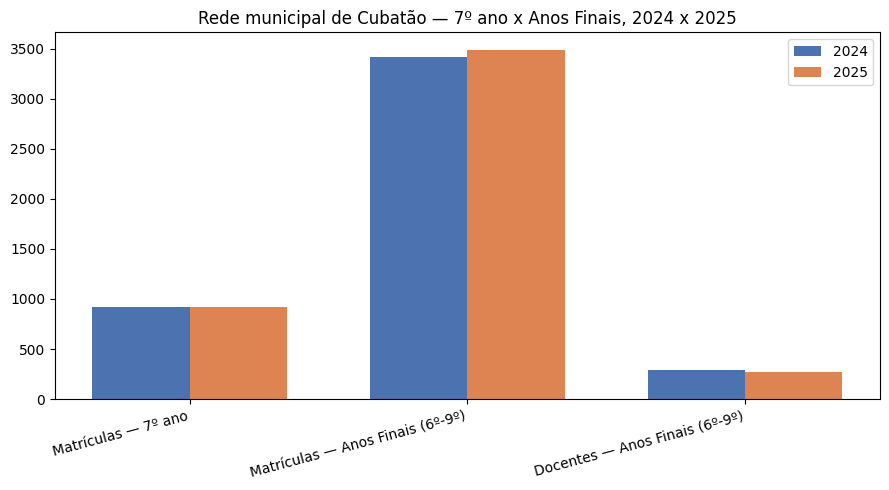

In [4]:
# 1.3 Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(resumo.index))
largura = 0.35
ax.bar(x - largura/2, resumo['2024'], largura, label='2024', color=COR_2024)
ax.bar(x + largura/2, resumo['2025'], largura, label='2025', color=COR_2025)
ax.set_xticks(x)
ax.set_xticklabels(resumo.index, rotation=15, ha='right')
ax.set_title('Rede municipal de Cubatão — 7º ano x Anos Finais, 2024 x 2025')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Taxas de Rendimento — rede municipal de Cubatão (2024 x 2025)

Agregado municipal, 7º ano x Anos Finais (6º-9º) completos.


In [5]:
# 2.1 Agregado municipal — 7º ano x Anos Finais
rend_mun_2024 = pd.read_csv(f"{DADOS}/2024_cubatao_taxas_rendimento_municipio.csv")
rend_mun_2025 = pd.read_csv(f"{DADOS}/2025_cubatao_taxas_rendimento_municipio.csv")
rend_mun = pd.concat([rend_mun_2024, rend_mun_2025], ignore_index=True).set_index('NU_ANO_CENSO')

rend_7ano = rend_mun[['1_CAT_FUN_07', '2_CAT_FUN_07', '3_CAT_FUN_07']]
rend_7ano.columns = ['Aprovação', 'Reprovação', 'Abandono']

rend_af = rend_mun[['1_CAT_FUN_AF', '2_CAT_FUN_AF', '3_CAT_FUN_AF']]
rend_af.columns = ['Aprovação', 'Reprovação', 'Abandono']

print("7º ano:"); print(rend_7ano)
print("\nAnos Finais (6º-9º):"); print(rend_af)


7º ano:
              Aprovação  Reprovação  Abandono
NU_ANO_CENSO                                 
2024               91.7         7.3       1.0
2025               93.1         5.4       1.5

Anos Finais (6º-9º):
              Aprovação  Reprovação  Abandono
NU_ANO_CENSO                                 
2024               92.8         6.4       0.8
2025               94.4         4.6       1.0


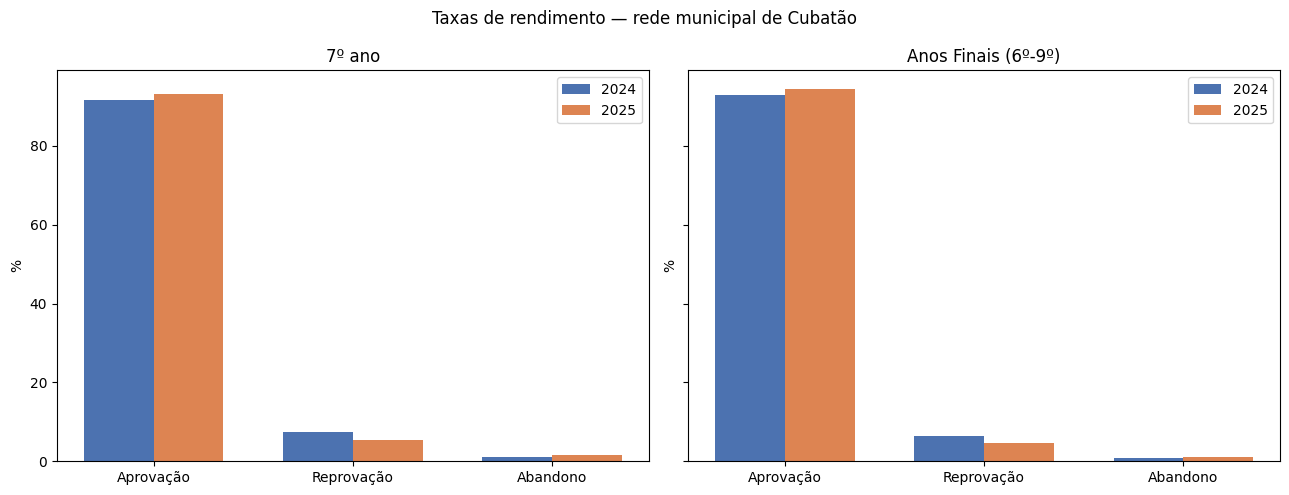

In [6]:
# 2.2 Gráfico comparativo: 7º ano x Anos Finais, 2024 x 2025
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, dados, titulo in zip(axes, [rend_7ano, rend_af], ['7º ano', 'Anos Finais (6º-9º)']):
    x = np.arange(len(dados.columns))
    largura = 0.35
    ax.bar(x - largura/2, dados.loc[2024], largura, label='2024', color=COR_2024)
    ax.bar(x + largura/2, dados.loc[2025], largura, label='2025', color=COR_2025)
    ax.set_xticks(x)
    ax.set_xticklabels(dados.columns)
    ax.set_title(titulo)
    ax.set_ylabel('%')
    ax.legend()
plt.suptitle('Taxas de rendimento — rede municipal de Cubatão')
plt.tight_layout()
plt.show()


## 3. Estudo de caso (2026) — "Escola Municipal de Cubatão" (nome fictício)

**16 turmas, do 6º ao 9º ano.** 7º, 8º e 9º ano são chamada real digitalizada; 6º ano é simulado (mesmo método estatístico do turno da tarde), porque o arquivo original não trazia 6º ano.


In [7]:
# 3.1 Carregar a frequência mensal (6º a 9º ano — 6º fictício, demais reais)
freq_mensal = pd.read_csv(f"{DADOS}/2026_frequencia_mensal_por_aluno_6a9.csv")
freq_mensal_validos = freq_mensal[freq_mensal['tem_dados_no_mes']].copy()

resumo_origem = freq_mensal_validos.drop_duplicates(['serie','turma','aluno_numero']).groupby(['serie', 'origem']).size()
print("Alunos por série e origem do dado:")
print(resumo_origem)
print(f"\nTotal de turmas: {freq_mensal['turma'].nunique()} | Total de alunos: {freq_mensal.groupby('turma')['aluno_numero'].nunique().sum()}")


Alunos por série e origem do dado:
serie   origem  
6º ano  fictício    104
7º ano  real         94
8º ano  real        137
9º ano  real         90
dtype: int64

Total de turmas: 16 | Total de alunos: 425


In [8]:
# 3.2 Frequência média por série e por mês
ordem_meses = ['MAIO', 'JUNHO', 'JULHO', 'AGOSTO']
ordem_series = ['6º ano', '7º ano', '8º ano', '9º ano']

freq_serie_mes = (
    freq_mensal_validos.groupby(['serie', 'mes'])['frequencia_pct'].mean()
    .unstack()[ordem_meses].reindex(ordem_series)
)
freq_serie_mes.round(1)


mes,MAIO,JUNHO,JULHO,AGOSTO
serie,,,,
6º ano,89.2,90.1,88.6,86.6
7º ano,83.1,77.2,79.7,79.1
8º ano,82.6,74.3,74.5,79.6
9º ano,81.5,79.0,71.9,75.8


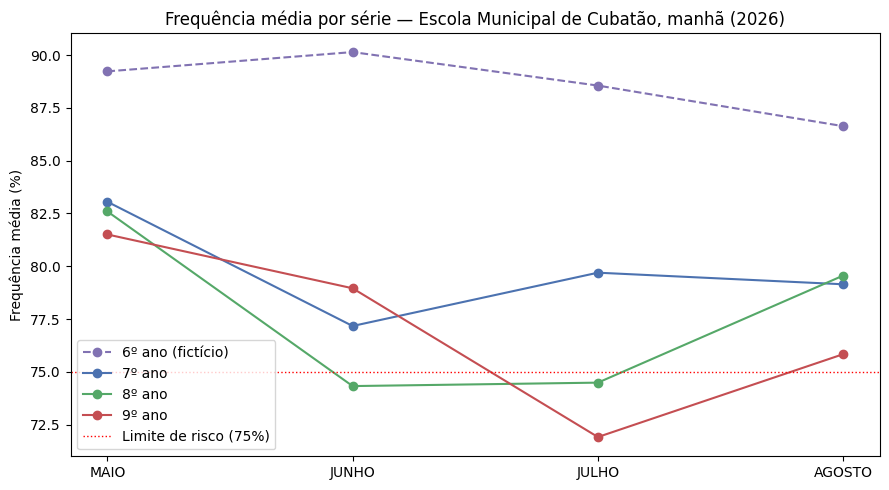

In [9]:
# 3.3 Gráfico: frequência média por série ao longo do trimestre
fig, ax = plt.subplots(figsize=(9, 5))
cores_serie = {'6º ano': '#8172B2', '7º ano': '#4C72B0', '8º ano': '#55A868', '9º ano': '#C44E52'}
for serie in ordem_series:
    linestyle = '--' if serie == '6º ano' else '-'  # tracejado sinaliza dado fictício
    ax.plot(ordem_meses, freq_serie_mes.loc[serie], marker='o', label=serie + (' (fictício)' if serie=='6º ano' else ''),
            color=cores_serie[serie], linestyle=linestyle)
ax.axhline(75, color='red', linestyle=':', linewidth=1, label='Limite de risco (75%)')
ax.set_ylabel('Frequência média (%)')
ax.set_title('Frequência média por série — Escola Municipal de Cubatão, manhã (2026)')
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
# 3.4 % de alunos em risco (frequência < 75% em algum mês), por série
risco_aluno_turma = (
    freq_mensal_validos.groupby(['serie', 'turma', 'aluno_numero'])['risco_abaixo_75pct'].any()
)
risco_serie = (
    risco_aluno_turma.groupby('serie').agg(total='count', em_risco='sum').reindex(ordem_series)
)
risco_serie['pct_em_risco'] = (risco_serie['em_risco'] / risco_serie['total'] * 100).round(1)

total_geral = risco_serie['total'].sum()
risco_geral = risco_serie['em_risco'].sum()
print(f"Escola inteira (6º-9º, manhã): {risco_geral} de {total_geral} alunos em risco em algum mês ({risco_geral/total_geral:.1%})")
risco_serie

Escola inteira (6º-9º, manhã): 234 de 425 alunos em risco em algum mês (55.1%)


,total,em_risco,pct_em_risco
serie,,,
6º ano,104,18,17.3
7º ano,94,53,56.4
8º ano,137,96,70.1
9º ano,90,67,74.4


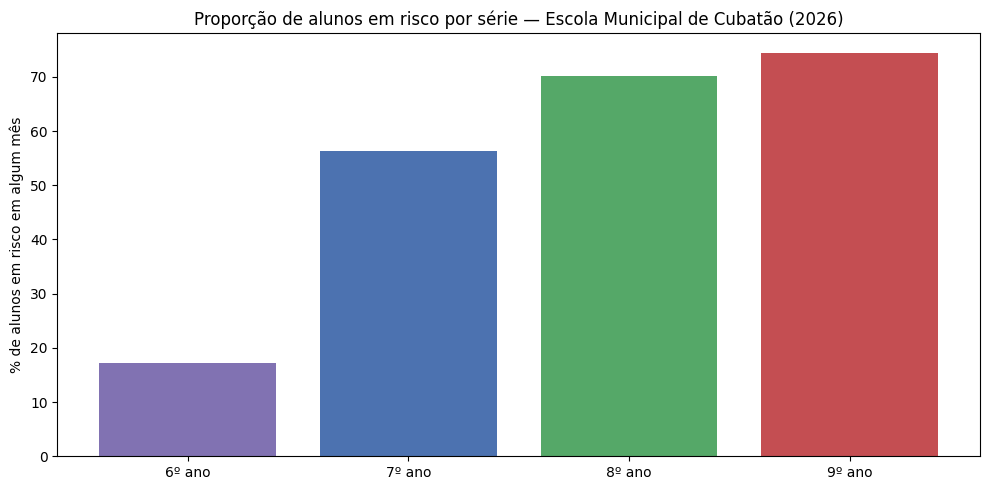

In [11]:
# 3.5 Gráfico: % em risco por série
fig, ax = plt.subplots()
cores_barra = [cores_serie[s] for s in risco_serie.index]
ax.bar(risco_serie.index, risco_serie['pct_em_risco'], color=cores_barra)
ax.set_ylabel('% de alunos em risco em algum mês')
ax.set_title('Proporção de alunos em risco por série — Escola Municipal de Cubatão (2026)')
plt.tight_layout()
plt.show()


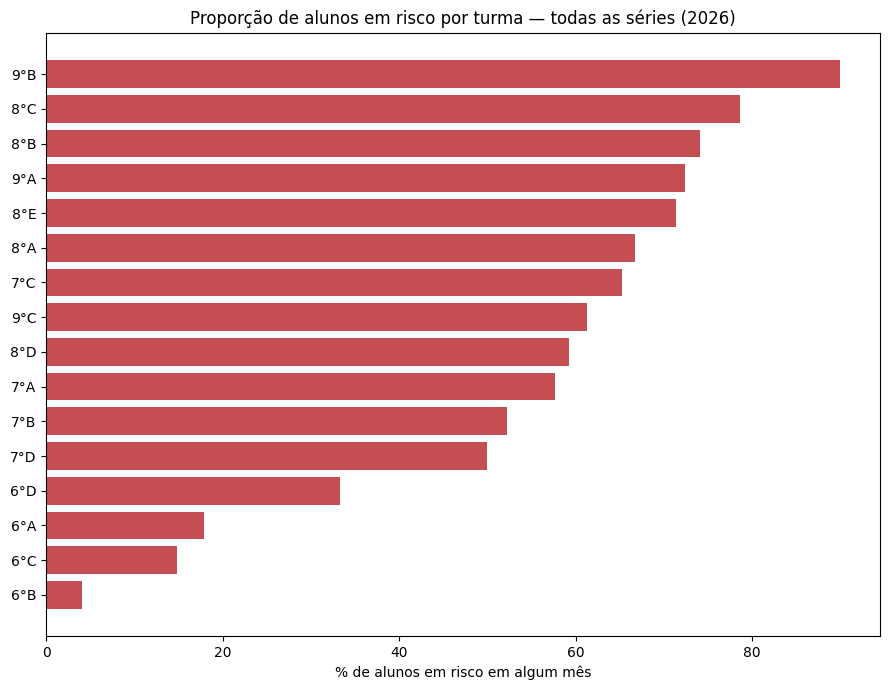

In [12]:
# 3.6 % de alunos em risco por turma (16 turmas)
risco_turma = (
    freq_mensal_validos.groupby(['turma', 'aluno_numero'])['risco_abaixo_75pct'].any()
    .groupby('turma').agg(total='count', em_risco='sum')
)
risco_turma['pct_em_risco'] = (risco_turma['em_risco'] / risco_turma['total'] * 100).round(1)
risco_turma = risco_turma.sort_values('pct_em_risco')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(risco_turma.index, risco_turma['pct_em_risco'], color='#C44E52')
ax.set_xlabel('% de alunos em risco em algum mês')
ax.set_title('Proporção de alunos em risco por turma — todas as séries (2026)')
plt.tight_layout()
plt.show()


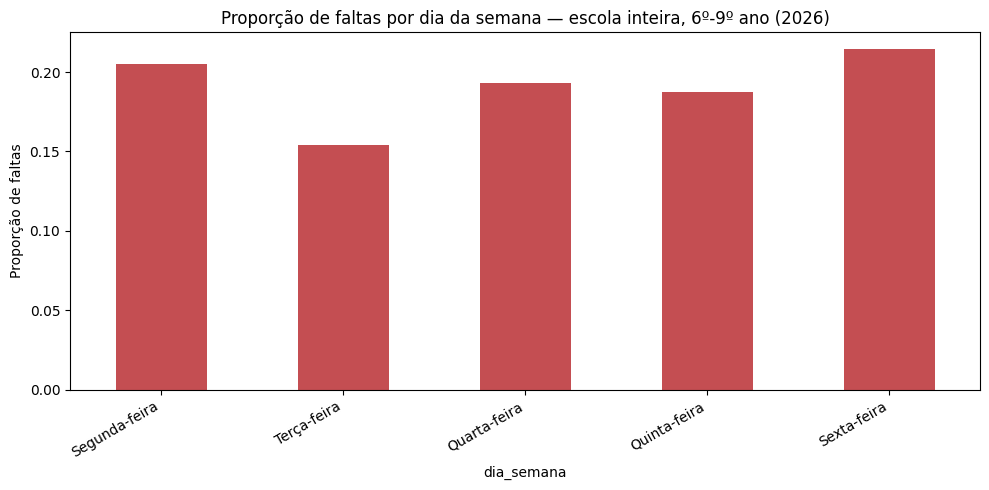

In [13]:
# 3.7 Chamada diária — faltas por dia da semana, escola inteira (6º-9º)
DIAS_PT = {'Monday':'Segunda-feira','Tuesday':'Terça-feira','Wednesday':'Quarta-feira','Thursday':'Quinta-feira','Friday':'Sexta-feira'}
ORDEM_DIAS_PT = ['Segunda-feira','Terça-feira','Quarta-feira','Quinta-feira','Sexta-feira']

chamada = pd.read_csv(f"{DADOS}/2026_chamada_diaria_longa_6a9.csv")
chamada['data'] = pd.to_datetime(chamada['data'])
chamada['dia_semana'] = chamada['data'].dt.day_name().map(DIAS_PT)

faltas_dia = (
    chamada[chamada['status'].isin(['P','F'])].groupby('dia_semana')['status']
    .apply(lambda s: (s=='F').mean()).reindex(ORDEM_DIAS_PT)
)

fig, ax = plt.subplots()
faltas_dia.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_ylabel('Proporção de faltas')
ax.set_title('Proporção de faltas por dia da semana — escola inteira, 6º-9º ano (2026)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 4. Índice de risco combinado

Aplicado às 425 combinações aluno×turma da escola inteira (6º a 9º ano), com "série" agora como variável real.


In [14]:
# 4.1 Calcular o índice de risco (3 sinais) por aluno x turma
def faltas_consecutivas_max(chamada_aluno):
    status = chamada_aluno.sort_values('data')['status']
    m = a = 0
    for s in status:
        if s == 'F': a += 1; m = max(m, a)
        elif s == 'P': a = 0
    return m

registros_risco = []
for (turma, aluno), grupo in freq_mensal_validos.groupby(['turma', 'aluno_numero']):
    go = grupo.set_index('mes').reindex(ordem_meses)['frequencia_pct'].dropna()
    if go.empty: continue
    fm = go.mean()
    tend = (go.iloc[-1] - go.iloc[0]) if len(go) >= 2 else 0
    fc = faltas_consecutivas_max(chamada[(chamada['turma']==turma) & (chamada['aluno_numero']==aluno)])

    pontos = 0
    if fm < 75: pontos += 3
    elif fm < 85: pontos += 1
    if tend <= -10: pontos += 2
    elif tend <= -5: pontos += 1
    if fc >= 3: pontos += 2
    elif fc >= 2: pontos += 1
    nivel = 'Alto' if pontos >= 5 else 'Médio' if pontos >= 2 else 'Baixo'

    registros_risco.append({
        'turma': turma, 'aluno_numero': aluno, 'serie': turma[0] + 'º ano',
        'frequencia_media': round(fm,1), 'tendencia_pp': round(tend,1),
        'faltas_consecutivas_max': fc, 'pontos_risco': pontos, 'nivel_risco': nivel
    })

indicador_risco = pd.DataFrame(registros_risco).sort_values('pontos_risco', ascending=False)
print(f"Total de alunos avaliados: {len(indicador_risco)}")
indicador_risco.head(10)


Total de alunos avaliados: 425


,turma,aluno_numero,serie,frequencia_media,tendencia_pp,faltas_consecutivas_max,pontos_risco,nivel_risco
85,6°D,6,6º ano,65.0,-30.0,5,7,Alto
387,9°B,27,9º ano,65.6,-14.8,3,7,Alto
146,7°B,20,7º ano,46.7,-80.0,8,7,Alto
203,8°A,7,8º ano,60.0,-25.0,3,7,Alto
121,7°A,22,7º ano,53.3,-43.2,6,7,Alto
124,7°A,25,7º ano,70.3,-21.8,3,7,Alto
378,9°B,17,9º ano,64.4,-11.7,5,7,Alto
268,8°C,19,8º ano,60.3,-15.9,3,7,Alto
375,9°B,14,9º ano,57.7,-23.5,5,7,Alto
235,8°B,12,8º ano,59.6,-55.0,3,7,Alto


nivel_risco
Baixo    139
Médio    151
Alto     135
Name: count, dtype: int64
nivel_risco
Baixo    32.7
Médio    35.5
Alto     31.8
Name: count, dtype: float64


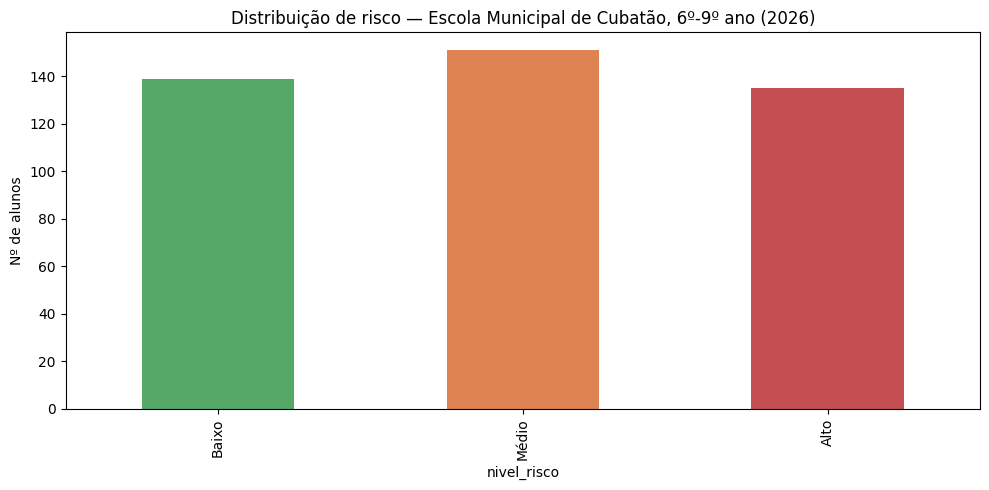

In [15]:
# 4.2 Distribuição geral por nível de risco
distribuicao_risco = indicador_risco['nivel_risco'].value_counts().reindex(['Baixo','Médio','Alto'])
print(distribuicao_risco)
print((distribuicao_risco / distribuicao_risco.sum() * 100).round(1))

fig, ax = plt.subplots()
cores_risco = {'Baixo': '#55A868', 'Médio': '#DD8452', 'Alto': '#C44E52'}
distribuicao_risco.plot(kind='bar', ax=ax, color=[cores_risco[n] for n in distribuicao_risco.index])
ax.set_ylabel('Nº de alunos')
ax.set_title('Distribuição de risco — Escola Municipal de Cubatão, 6º-9º ano (2026)')
plt.tight_layout()
plt.show()


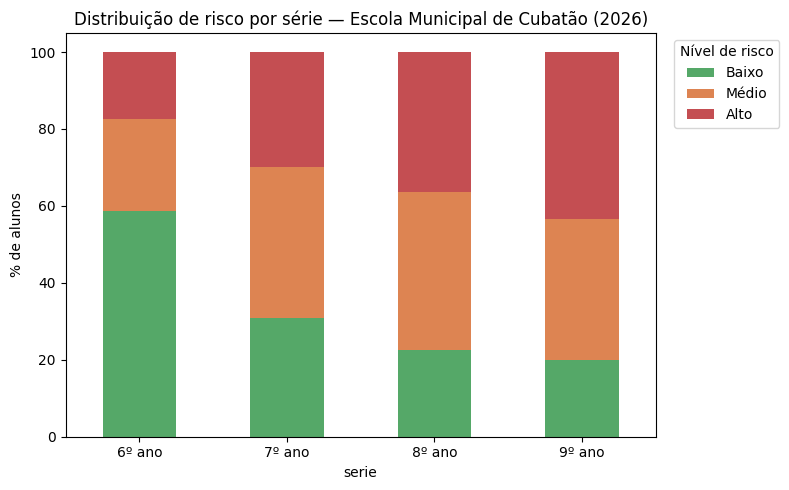

In [16]:
# 4.3 Distribuição de risco por série
dist_serie = indicador_risco.groupby(['serie', 'nivel_risco']).size().unstack(fill_value=0).reindex(index=ordem_series, columns=['Baixo','Médio','Alto'])
dist_serie_pct = dist_serie.div(dist_serie.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
dist_serie_pct.plot(kind='bar', stacked=True, ax=ax, color=[cores_risco[c] for c in dist_serie_pct.columns])
ax.set_ylabel('% de alunos')
ax.set_title('Distribuição de risco por série — Escola Municipal de Cubatão (2026)')
ax.legend(title='Nível de risco', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### O paradoxo entre a taxa oficial e o caso real — agora no mesmo recorte (Anos Finais)

Com o estudo de caso cobrindo 6º a 9º ano, a comparação com a taxa oficial de **Anos Finais** (Bloco 2) é mais direta do que quando só tínhamos o 7º ano isoladamente. Ainda assim, duas ressalvas continuam válidas:

1. **Cobertura parcial.** O estudo de caso é de uma única escola, turno da manhã — a taxa oficial é o agregado de **toda a rede municipal** (54 escolas, manhã e tarde). E a turma de 6º ano específica é **fictícia**, o que deve ser lembrado ao interpretar qualquer diferença entre séries.
2. **Indicador de resultado x indicador antecedente.** Taxas de aprovação/reprovação são o resultado de **fim de ano**; frequência é um sinal **antecedente**, que aparece antes.

O ganho real desta versão é poder comparar **série a série dentro da própria escola** (Blocos 3.4–3.6 e 4.3) — e não apenas o 7º ano contra a média da rede.


## 5. Síntese e próximos passos

- [ ] Redigir a análise textual final incorporando o recorte completo de Anos Finais (6º-9º)
- [ ] Deixar claro, em qualquer apresentação do PI, que o 6º ano do estudo de caso é fictício (as demais séries são reais)
- [ ] Investigar por que certas séries/turmas concentram mais risco (Blocos 3.4–3.6 e 4.3)
- [ ] Se possível, obter dados reais de 6º ano futuramente, substituindo a simulação
- [ ] Buscar Taxas de Rendimento de anos anteriores a 2024 para ampliar a série histórica municipal
